# Linkography Code Annotation Implementation

## TRY: Detect ONE linkography pattern using ONE or TWO annotation codes

Remember, these sessions' JSON files were split into 10 minute segments. Might have to fix this again if we are to scale implementation etc.

## Iteration 1

In [2]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
# In this file, utterances live inside "all_data"
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
#    (use index as a fallback utterance_id)
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),   # could be None here; that's fine for now
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

# Quick sanity check: how many have non-empty annotations?
non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# Show a couple of examples so you can eyeball them
for u in utterances[:3]:
    print("\n--- Example utterance ---")
    print("utterance_id:", u["utterance_id"])
    print("speaker:", u["speaker"])
    print("timestamp:", u["timestamp"])
    print("annotations keys:", list(u["annotations"].keys()))
    print("snippet:", u["transcript"][:120])


# --------------------------------------------------------
# 4. Define heuristic for “short-span forelink”
#    We treat certain annotation categories as "builds on / responds to"
#    and link each such utterance to the *immediately previous* one.
# --------------------------------------------------------
def detect_short_span_forelinks(utterances):
    links = []

    # Categories that usually indicate a move that builds on
    # or responds to prior talk (you can tweak this set)
    build_categories = [
        "Knowledge Sharing",
        "Coordination and Decision Practices",
        "Participation Dynamics",
        "Communication Practices",
        "Goal/Focus Clarity",
        "Trust and Psychological Safety",
        "Conflict Management"
    ]

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # If the current utterance has *any* of these categories,
        # treat it as a short-span forelink from previous → current
        if any(cat in ann_curr for cat in build_categories):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "categories_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links


# --------------------------------------------------------
# 5. Run detection and inspect a few links
# --------------------------------------------------------
links_found = detect_short_span_forelinks(utterances)

print(f"\nDetected {len(links_found)} short-span forelinks.")
for link in links_found[:10]:
    print("\n--- Forelink ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

--- Example utterance ---
utterance_id: utt_0
speaker: Anna Moore
timestamp: 00:00-00:23
annotations keys: ['Coordination and Decision Practices', 'Information Seeking']
snippet: suggest is that we very quickly introduce ourselves um and then we'll start working on generating ideas. So is there any

--- Example utterance ---
utterance_id: utt_1
speaker: Anna Moore
timestamp: 00:23-01:57
annotations keys: ['Knowledge Sharing', 'Coordination and Decision Practices']
snippet: So I thought I thought we all first facilitators introduce themselves. But

## Iteration 2

In [3]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file.  2021-05-21-ABI-S4
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# --------------------------------------------------------
# 4. Helper: does this utterance look "idea-building"?
# --------------------------------------------------------
IDEA_CODES = {
    "Idea Management",
    "Knowledge Sharing",
    "Evaluation Practices",
    "Integration Practices",
}

def is_idea_building(ann_dict):
    """
    ann_dict: {"CodeName": {"explanation": ..., "score": ..., "when": ...}, ...}
    Returns True if the utterance has at least one idea-related code
    that is NOT just an intro / "beginning" meta move.
    """
    for code, info in ann_dict.items():
        if code in IDEA_CODES:
            when = (info or {}).get("when", "").lower()
            if when != "beginning":   # exclude introductions
                return True
    return False

# --------------------------------------------------------
# 5. Detect short-span forelinks *only for idea-building moves*
# --------------------------------------------------------
def detect_short_span_forelinks_v2(utterances):
    links = []

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # New heuristic: only link if current utterance is "idea-building"
        if is_idea_building(ann_curr):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink_v2",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "timestamp_curr": curr_u["timestamp"],
                "codes_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links

# --------------------------------------------------------
# 6. Run detection and compare
# --------------------------------------------------------
links_v2 = detect_short_span_forelinks_v2(utterances)

print(f"\nIteration 2: detected {len(links_v2)} idea-building short-span forelinks.")
for link in links_v2[:10]:
    print("\n--- Forelink v2 ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

Iteration 2: detected 127 idea-building short-span forelinks.

--- Forelink v2 ---
from: utt_67
to: utt_68
type: short_span_forelink_v2
speaker_from: Benjamin Bartelle
speaker_to: Benjamin Bartelle
timestamp_curr: 06:09-07:08
codes_curr: ['Knowledge Sharing', 'Information Seeking', 'Relational Climate']
snippet_prev: I think some of us are you can study people though, right?
snippet_curr: Um Molly, you study people, but what you get is not mechanistic per se. It's like a convolution of the mechanisms. And s

--- Forelink v2 ---
from: utt_68
to: u

# Stopping the Iteration Implementation. Now Reflecting on it all

# Code Sequences, Couplets & Triplets

Stay with the current annotation codes

Build sequences ("couplets") with temporal info

Summarize per session (this is in a table output)
- How often each code appears
- How often each transition (pair) appears
- Where (beginning/middle/end) those transitions show up

**reminder: also need to handle the 10 minute chunks**

In [4]:
import os
import json
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 0. CONFIG
# ----------------------------------------------------
# Change this to the root folder that contains
# 2020NES, 2021SLU, 2021NES, 2021MZT, etc.
# e.g., BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/v2-data"
BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"

# Map the human-readable code labels (in JSON) to safe column names
CODE_MAP = {
    "Idea Management": "Idea_Management",
    "Information Seeking": "Information_Seeking",
    "Knowledge Sharing": "Knowledge_Sharing",
    "Evaluation Practices": "Evaluation_Practices",
    "Relational Climate": "Relational_Climate",
    "Participation Dynamics": "Participation_Dynamics",
    "Coordination and Decision Practices": "Coordination_and_Decision_Practices",
    "Integration Practices": "Integration_Practices",
}

CODE_LABELS = list(CODE_MAP.keys())
CODE_COLS   = list(CODE_MAP.values())


# ----------------------------------------------------
# 1. Small helpers: time + region
# ----------------------------------------------------
def parse_hhmmss_to_sec(t):
    """
    t like '00:00' or '01:23:45'.
    Returns seconds as int. If bad format, returns np.nan.
    """
    if not isinstance(t, str) or not t.strip():
        return np.nan
    parts = t.strip().split(":")
    try:
        parts = [int(p) for p in parts]
    except ValueError:
        return np.nan

    if len(parts) == 2:  # mm:ss
        mm, ss = parts
        return mm * 60 + ss
    elif len(parts) == 3:  # hh:mm:ss
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    else:
        return np.nan


def assign_region_for_session(df_session):
    """
    Given a single-session DataFrame with 'mid_sec', add 'region' 
    (Beginning / Middle / End) based on thirds of the time.
    """
    max_t = df_session["mid_sec"].max()
    if pd.isna(max_t) or max_t <= 0:
        # default everything to Middle if we don't have good timing
        df_session["region"] = "Middle"
        return df_session

    b_cut = max_t / 3.0
    m_cut = 2.0 * max_t / 3.0

    def _region(m):
        if m < b_cut:
            return "Beginning"
        elif m < m_cut:
            return "Middle"
        else:
            return "End"

    df_session["region"] = df_session["mid_sec"].apply(_region)
    return df_session


# ----------------------------------------------------
# 2. Flatten a single JSON session file
# ----------------------------------------------------
def flatten_session_json(json_path):
    """
    Read one SCIALOG-style JSON:
      {
        "all_speakers": [...],
        "total_speaking_length": ...,
        "all_data": [
           {
             "speaker": ...,
             "timestamp": "00:00-00:38",
             "start_time": "00:00",
             "end_time": "00:38",
             "annotations": {
                 "Idea Management": {"score": 2, "when": "middle", ...},
                 ...
             },
             ...
           },
           ...
        ]
      }
    Return a list of dict rows (one per utterance).
    """
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed to load {json_path}: {e}")
        return []

    # figure out conference + session IDs
    # .../2021SLU/session_data/2021_06_11_SLU_S3.json
    session_filename = os.path.basename(json_path)
    session_id = os.path.splitext(session_filename)[0]
    conference = os.path.basename(os.path.dirname(os.path.dirname(json_path)))

    # determine where utterances are stored
    if isinstance(data, dict):
        all_data = data.get("all_data", [])
    elif isinstance(data, list):
        all_data = data
    else:
        all_data = []

    if not all_data:
        print(f"[WARN] Skipping {json_path} — empty or missing all_data.")
        return []

    rows = []
    for entry in all_data:
        if not isinstance(entry, dict):
            continue

        speaker = entry.get("speaker")
        timestamp_raw = entry.get("timestamp")
        start_time = entry.get("start_time")
        end_time = entry.get("end_time")

        # If start_time / end_time missing, try parsing from timestamp
        if (not start_time or not end_time) and isinstance(timestamp_raw, str) and "-" in timestamp_raw:
            start_raw, end_raw = timestamp_raw.split("-", 1)
            start_time = start_time or start_raw.strip()
            end_time = end_time or end_raw.strip()

        start_sec = parse_hhmmss_to_sec(start_time)
        end_sec   = parse_hhmmss_to_sec(end_time)
        if pd.isna(start_sec) or pd.isna(end_sec):
            mid_sec = np.nan
        else:
            mid_sec = (start_sec + end_sec) / 2.0

        # Screenshare / gesture at top level
        screenshare = entry.get("screenshare")
        hand_gesture = entry.get("hand_gesture")

        # Annotations dict
        annotations = entry.get("annotations") or {}

        row = {
            "conference": conference,
            "session": session_id,
            "speaker": speaker,
            "timestamp_raw": timestamp_raw,
            "start_time": start_time,
            "end_time": end_time,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "mid_sec": mid_sec,
            "speaking_duration": entry.get("speaking_duration"),
            "screenshare": screenshare,
            "hand_gesture": hand_gesture,
            # keep raw annotations for debugging
            "annotations_raw": annotations,
        }

        # For each of the 8 codes, create a 0/1 presence flag from "score"
        for label, colname in CODE_MAP.items():
            ann = annotations.get(label, {})
            present = 0
            if isinstance(ann, dict):
                score = ann.get("score", None)
                if score is not None and score != "" and not pd.isna(score):
                    try:
                        present = int(float(score) > 0)
                    except Exception:
                        # fallback: if score is set at all, consider it present
                        present = 1
            row[colname] = present

        rows.append(row)

    return rows


# ----------------------------------------------------
# 3. Build df_events over all conferences / sessions
# ----------------------------------------------------
all_rows = []

for conf_dir in sorted(os.listdir(BASE_DIR)):
    conf_path = os.path.join(BASE_DIR, conf_dir)
    if not os.path.isdir(conf_path):
        continue

    session_dir = os.path.join(conf_path, "session_data")
    if not os.path.isdir(session_dir):
        continue

    for fname in sorted(os.listdir(session_dir)):
        if not fname.endswith(".json"):
            continue
        fpath = os.path.join(session_dir, fname)
        rows = flatten_session_json(fpath)
        all_rows.extend(rows)

df_events = pd.DataFrame(all_rows)
print("df_events shape:", df_events.shape)
print("Columns:", df_events.columns.tolist())

# ----------------------------------------------------
# 3a. Add region + minute columns
# ----------------------------------------------------
# Region assignment (Beginning/Middle/End) per session
df_regions = []
for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
    sub_copy = sub.copy()
    sub_copy = assign_region_for_session(sub_copy)
    df_regions.append(sub_copy)

df_events = pd.concat(df_regions, ignore_index=True)

# Minute-level time (integer minute from start)
df_events["start_minute"] = (df_events["start_sec"] // 60).fillna(-1).astype(int)
df_events["end_minute"]   = (df_events["end_sec"]   // 60).fillna(-1).astype(int)
df_events["mid_minute"]   = (df_events["mid_sec"]   // 60).fillna(-1).astype(int)

print("Region counts:")
print(df_events["region"].value_counts(dropna=False))


# ----------------------------------------------------
# 4. Session-level summary features
# ----------------------------------------------------
# Basic session stats
session_group = df_events.groupby(["conference", "session"], as_index=False)

df_session_features = session_group.agg(
    n_utterances=("speaker", "size"),
    n_speakers=("speaker", pd.Series.nunique),
    max_time=("end_sec", "max"),
)

# Region distribution per session
region_counts = (
    df_events
    .groupby(["conference", "session", "region"])
    .size()
    .reset_index(name="region_count")
)

region_pivot = region_counts.pivot(
    index=["conference", "session"],
    columns="region",
    values="region_count"
).fillna(0)

for r in ["Beginning", "Middle", "End"]:
    if r not in region_pivot.columns:
        region_pivot[r] = 0

region_pivot = region_pivot[["Beginning", "Middle", "End"]].reset_index()

# Code counts per session (how many utterances had each code present)
code_counts = (
    df_events
    .groupby(["conference", "session"])[CODE_COLS]
    .sum()
    .reset_index()
)

# Merge all session-level features
df_session_features = (
    df_session_features
    .merge(region_pivot, on=["conference", "session"], how="left")
    .merge(code_counts, on=["conference", "session"], how="left")
)

df_session_features[CODE_COLS] = df_session_features[CODE_COLS].fillna(0).astype(int)

print("df_session_features shape:", df_session_features.shape)
print(df_session_features.head())


# ----------------------------------------------------
# 5. Build code couplets (transitions) per session
# ----------------------------------------------------
# First, filter utterances that have at least one active code
df_events["any_code"] = df_events[CODE_COLS].sum(axis=1) > 0
print("Rows with any active code:", df_events["any_code"].sum(), "out of", len(df_events))

active = df_events[df_events["any_code"]].copy()

if active.empty:
    print("No active-coded utterances were found — couplets will be empty for now.")
    df_couplets = pd.DataFrame()
else:
    # Sort by time within each session
    active = active.sort_values(["conference", "session", "start_sec"]).reset_index(drop=True)

    records = []
    for (conf, sess), sub in active.groupby(["conference", "session"], sort=False):
        prev_codes = None
        prev_region = None
        prev_time = None

        for _, row in sub.iterrows():
            # which codes are active in this utterance?
            this_codes = [c for c in CODE_COLS if row[c] == 1]
            if not this_codes:
                continue

            if prev_codes is not None:
                # create all pair-wise transitions prev_code -> this_code
                for from_code in prev_codes:
                    for to_code in this_codes:
                        records.append({
                            "conference": conf,
                            "session": sess,
                            "from_code": from_code,
                            "to_code": to_code,
                            "from_region": prev_region,
                            "to_region": row["region"],
                            "from_time": prev_time,
                            "to_time": row["start_sec"],
                        })

            # update "previous" pointer
            prev_codes = this_codes
            prev_region = row["region"]
            prev_time = row["start_sec"]

    df_couplets = pd.DataFrame(records)

print("df_couplets shape:", df_couplets.shape)
print(df_couplets.head())


# ----------------------------------------------------
# 6. Aggregate couplet features (for model / viz)
# ----------------------------------------------------
if not df_couplets.empty:
    # Add minute-level for couplets
    df_couplets["from_minute"] = (df_couplets["from_time"] // 60).fillna(-1).astype(int)
    df_couplets["to_minute"]   = (df_couplets["to_time"]   // 60).fillna(-1).astype(int)

    # Overall couplet counts per session
    df_couplet_counts = (
        df_couplets
        .groupby(["conference", "session", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )

    print("df_couplet_counts sample:")
    print(df_couplet_counts.head())

    # Couplets by region of origin (Beginning/Middle/End)
    df_couplet_region = (
        df_couplets
        .groupby(["conference", "session", "from_region", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets_region")
    )

    print("df_couplet_region sample:")
    print(df_couplet_region.head())
else:
    df_couplet_counts = pd.DataFrame()
    df_couplet_region = pd.DataFrame()
    print("No couplet aggregates computed because df_couplets is empty.")


# ----------------------------------------------------
# 7. Minute-level code distribution (per session)
# ----------------------------------------------------
# Long-form table: how many times each code is active in each minute
minute_code_table = (
    df_events
    .melt(
        id_vars=["conference", "session", "mid_minute"],
        value_vars=CODE_COLS,
        var_name="code",
        value_name="active"
    )
    .query("active == 1")
    .groupby(["conference", "session", "mid_minute", "code"])
    .size()
    .reset_index(name="n_events")
)

print("minute_code_table shape:", minute_code_table.shape)
print(minute_code_table.head())


# ----------------------------------------------------
# 8. Minute-level couplet distribution
# ----------------------------------------------------
if not df_couplets.empty:
    minute_couplets = (
        df_couplets
        .groupby(["conference", "session", "from_minute", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )
    print("minute_couplets shape:", minute_couplets.shape)
    print(minute_couplets.head())
else:
    minute_couplets = pd.DataFrame()
    print("minute_couplets is empty because df_couplets is empty.")

df_events shape: (30558, 21)
Columns: ['conference', 'session', 'speaker', 'timestamp_raw', 'start_time', 'end_time', 'start_sec', 'end_sec', 'mid_sec', 'speaking_duration', 'screenshare', 'hand_gesture', 'annotations_raw', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices']
Region counts:
region
End          11644
Beginning    10054
Middle        8860
Name: count, dtype: int64
df_session_features shape: (157, 16)
  conference            session  n_utterances  n_speakers  max_time  \
0    2020NES  2020_11_05_NES_S1            82          12      3120   
1    2020NES  2020_11_05_NES_S2            67          11      3596   
2    2020NES  2020_11_05_NES_S3            45          10      3095   
3    2020NES  2020_11_05_NES_S4            41           9      3073   
4    2020NES  2020_11_05_NES_S5            28          11      3063   

   Begin

## Isolating 2021_05_21_ABI_S4

In [5]:
# ----------------------------------------------
# FILTER ONE SESSION: 2021_05_21_ABI_S4
# ----------------------------------------------
SESSION_ID = "2021_05_21_ABI_S4"
CONF_ID    = "2021ABI"   # conference folder name

events_s4 = df_events[
    (df_events["conference"] == CONF_ID) &
    (df_events["session"] == SESSION_ID)
].copy()

couplets_s4 = df_couplets[
    (df_couplets["conference"] == CONF_ID) &
    (df_couplets["session"] == SESSION_ID)
].copy()

minute_codes_s4 = minute_code_table[
    (minute_code_table["conference"] == CONF_ID) &
    (minute_code_table["session"] == SESSION_ID)
].copy()

minute_couplets_s4 = minute_couplets[
    (minute_couplets["conference"] == CONF_ID) &
    (minute_couplets["session"] == SESSION_ID)
].copy()

session_feat_s4 = df_session_features[
    (df_session_features["conference"] == CONF_ID) &
    (df_session_features["session"] == SESSION_ID)
].copy()

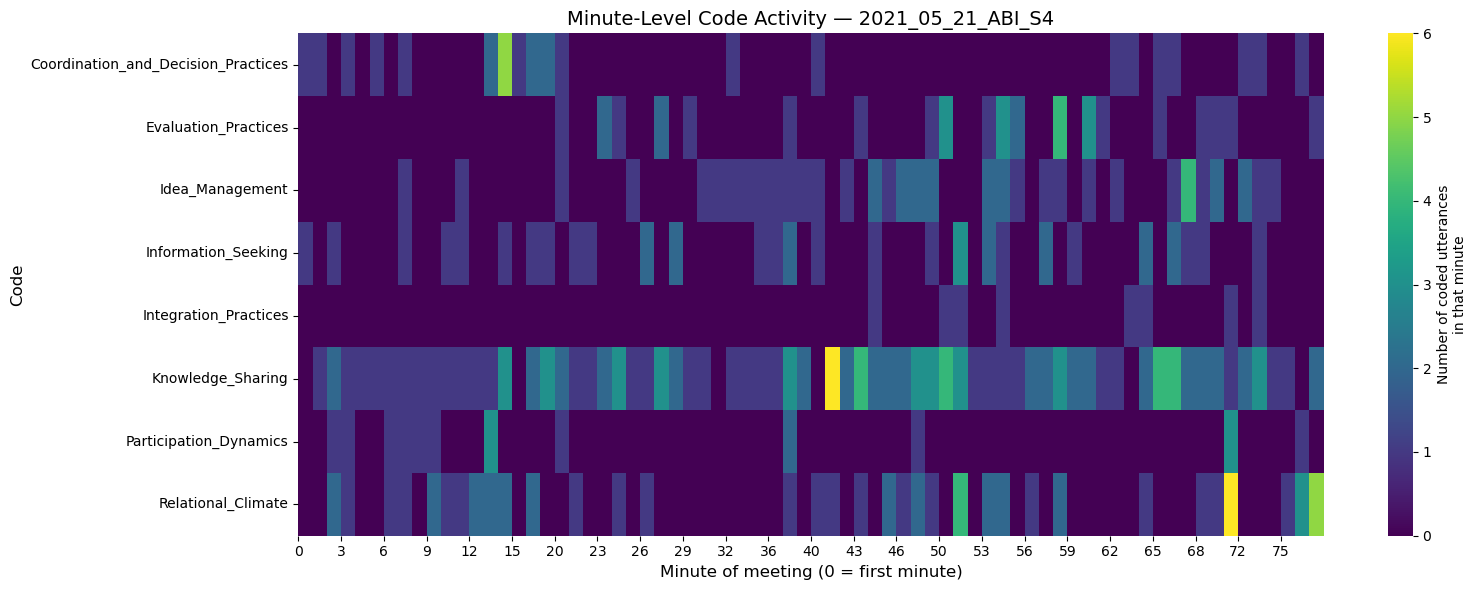

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot: rows = codes, columns = minute index, values = count of coded utterances
heat_df = (
    minute_codes_s4
    .pivot(index="code", columns="mid_minute", values="n_events")
    .fillna(0)
)

# Make sure minutes are in order
heat_df = heat_df.reindex(sorted(heat_df.columns), axis=1)

plt.figure(figsize=(16, 6))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    cbar_kws={"label": "Number of coded utterances\nin that minute"}
)

ax.set_title("Minute-Level Code Activity — 2021_05_21_ABI_S4", fontsize=14)
ax.set_ylabel("Code", fontsize=12)
ax.set_xlabel("Minute of meeting (0 = first minute)", fontsize=12)

# show x-ticks every 2–3 minutes to avoid clutter (tweak as needed)
xticks = sorted(heat_df.columns)
ax.set_xticks(range(0, len(xticks), 3))
ax.set_xticklabels(xticks[0::3])

plt.tight_layout()
plt.show()

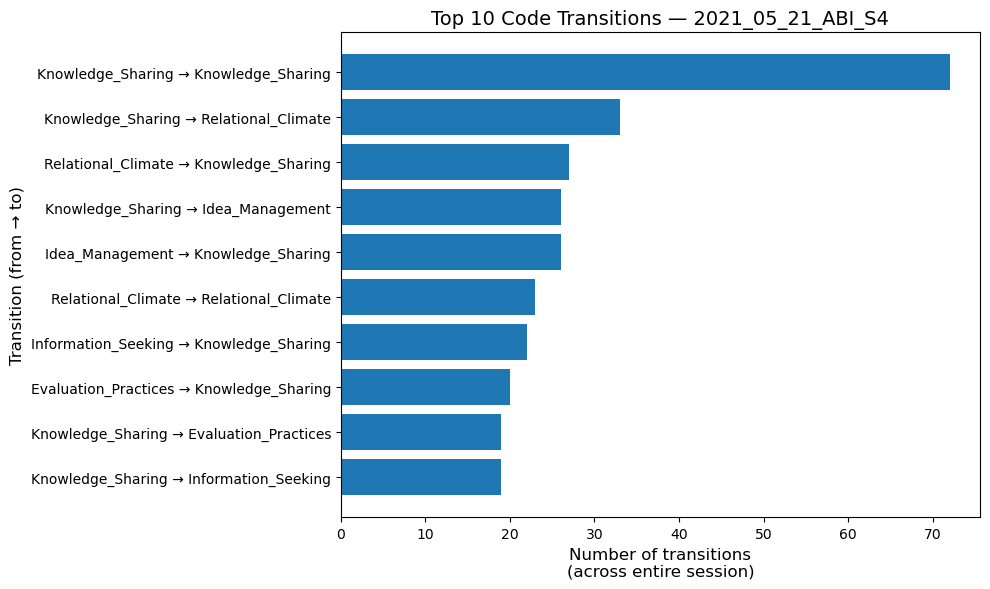

,from_code,to_code,n,pair_label
43,Knowledge_Sharing,Knowledge_Sharing,72,Knowledge_Sharing → Knowledge_Sharing
45,Knowledge_Sharing,Relational_Climate,33,Knowledge_Sharing → Relational_Climate
59,Relational_Climate,Knowledge_Sharing,27,Relational_Climate → Knowledge_Sharing
40,Knowledge_Sharing,Idea_Management,26,Knowledge_Sharing → Idea_Management
21,Idea_Management,Knowledge_Sharing,26,Idea_Management → Knowledge_Sharing
61,Relational_Climate,Relational_Climate,23,Relational_Climate → Relational_Climate
28,Information_Seeking,Knowledge_Sharing,22,Information_Seeking → Knowledge_Sharing
13,Evaluation_Practices,Knowledge_Sharing,20,Evaluation_Practices → Knowledge_Sharing
39,Knowledge_Sharing,Evaluation_Practices,19,Knowledge_Sharing → Evaluation_Practices
41,Knowledge_Sharing,Information_Seeking,19,Knowledge_Sharing → Information_Seeking


In [7]:
# Count transitions across the **entire session** (not per minute)
top_couplets = (
    couplets_s4
    .groupby(["from_code", "to_code"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)

# Combine into a single label like "KS → RC"
top_couplets["pair_label"] = (
    top_couplets["from_code"] + " → " + top_couplets["to_code"]
)

plt.figure(figsize=(10, 6))
plt.barh(top_couplets["pair_label"], top_couplets["n"])
plt.gca().invert_yaxis()  # biggest on top

plt.title("Top 10 Code Transitions — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Number of transitions\n(across entire session)", fontsize=12)
plt.ylabel("Transition (from → to)", fontsize=12)

plt.tight_layout()
plt.show()

top_couplets  # optional: print the table as well

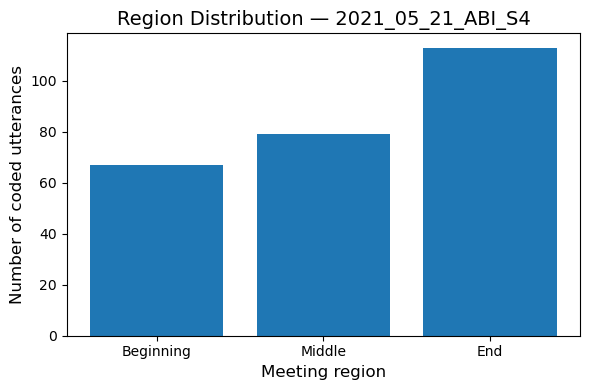

In [8]:
region_vals = session_feat_s4[["Beginning", "Middle", "End"]].iloc[0]

plt.figure(figsize=(6, 4))
plt.bar(region_vals.index, region_vals.values)

plt.title("Region Distribution — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Meeting region", fontsize=12)
plt.ylabel("Number of coded utterances", fontsize=12)


plt.tight_layout()
plt.show()

# Examining the Knowledge Sharing Sequences

In [9]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# STEP 1: Knowledge-Sharing sequences (streaks, regions, timing)
# -------------------------------------------------------------------

def compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing"):
    """
    For each (conference, session):
      - KS_total_utterances
      - KS_streak_count  (number of distinct runs of consecutive KS utterances)
      - KS_max_streak_len
      - KS_mean_streak_len
      - KS_beginning / KS_middle / KS_end counts
      - KS_first_minute, KS_last_minute, KS_mean_minute  (midpoint of KS utterances)
    Returns: DataFrame indexed by (conference, session).
    """
    rows = []

    # make sure region exists (you already computed it earlier)
    if "region" not in df_events.columns:
        raise ValueError("df_events is missing 'region' column. "
                         "Make sure you ran the region assignment step first.")

    for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
        sub = sub.sort_values("start_sec").reset_index(drop=True)

        # Basic KS presence
        ks_mask = sub[ks_col] == 1
        KS_total_utterances = int(ks_mask.sum())

        # If no KS at all, fill zeros and continue
        if KS_total_utterances == 0:
            rows.append({
                "conference": conf,
                "session": sess,
                "KS_total_utterances": 0,
                "KS_streak_count": 0,
                "KS_max_streak_len": 0,
                "KS_mean_streak_len": 0.0,
                "KS_beginning": 0,
                "KS_middle": 0,
                "KS_end": 0,
                "KS_first_minute": np.nan,
                "KS_last_minute": np.nan,
                "KS_mean_minute": np.nan,
            })
            continue

        # ---- Streaks of consecutive KS utterances ----
        streak_lengths = []
        in_streak = False
        cur_len = 0

        for is_ks in ks_mask:
            if is_ks:
                if not in_streak:
                    in_streak = True
                    cur_len = 1
                else:
                    cur_len += 1
            else:
                if in_streak:
                    streak_lengths.append(cur_len)
                    in_streak = False
                    cur_len = 0

        # close final streak
        if in_streak:
            streak_lengths.append(cur_len)

        KS_streak_count = len(streak_lengths)
        KS_max_streak_len = int(max(streak_lengths)) if streak_lengths else 0
        KS_mean_streak_len = float(np.mean(streak_lengths)) if streak_lengths else 0.0

        # ---- Region distribution of KS ----
        ks_region_counts = (
            sub.loc[ks_mask, "region"]
            .value_counts()
            .to_dict()
        )
        KS_beginning = int(ks_region_counts.get("Beginning", 0))
        KS_middle    = int(ks_region_counts.get("Middle", 0))
        KS_end       = int(ks_region_counts.get("End", 0))

        # ---- Timing of KS in minutes (using mid_sec) ----
        ks_times_sec = sub.loc[ks_mask, "mid_sec"].dropna().values
        if len(ks_times_sec) > 0:
            ks_minutes = ks_times_sec / 60.0
            KS_first_minute = float(np.min(ks_minutes))
            KS_last_minute  = float(np.max(ks_minutes))
            KS_mean_minute  = float(np.mean(ks_minutes))
        else:
            KS_first_minute = KS_last_minute = KS_mean_minute = np.nan

        rows.append({
            "conference": conf,
            "session": sess,
            "KS_total_utterances": KS_total_utterances,
            "KS_streak_count": KS_streak_count,
            "KS_max_streak_len": KS_max_streak_len,
            "KS_mean_streak_len": KS_mean_streak_len,
            "KS_beginning": KS_beginning,
            "KS_middle": KS_middle,
            "KS_end": KS_end,
            "KS_first_minute": KS_first_minute,
            "KS_last_minute": KS_last_minute,
            "KS_mean_minute": KS_mean_minute,
        })

    df_ks_features = pd.DataFrame(rows)
    return df_ks_features


df_ks_features = compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing")
print("df_ks_features shape:", df_ks_features.shape)
print(df_ks_features.head())

# -------------------------------------------------------------------
# STEP 2: Proto-linkography metrics from code couplets
# -------------------------------------------------------------------

def compute_linkography_features(df_couplets):
    """
    For each (conference, session), compute:
      - n_transitions
      - n_unique_pairs
      - transition_entropy (Shannon)
      - key KS-related transitions:
          KS->KS
          KS->Idea_Management
          Idea_Management->KS
          KS->Evaluation_Practices
          Evaluation_Practices->KS
          KS->Information_Seeking
          Information_Seeking->KS
          KS->Relational_Climate
          Relational_Climate->KS
    Returns: DataFrame indexed by (conference, session).
    """
    if df_couplets is None or df_couplets.empty:
        print("df_couplets is empty; returning empty linkography feature frame.")
        return pd.DataFrame(columns=[
            "conference", "session",
            "n_transitions", "n_unique_pairs", "transition_entropy",
            "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
            "KS_to_Eval", "Eval_to_KS",
            "KS_to_Info", "Info_to_KS",
            "KS_to_Rel", "Rel_to_KS",
        ])

    rows = []
    for (conf, sess), sub in df_couplets.groupby(["conference", "session"], sort=False):
        n_transitions = len(sub)

        # pair counts
        pair_counts = sub.groupby(["from_code", "to_code"]).size()
        n_unique_pairs = len(pair_counts)

        # entropy of transition distribution
        probs = pair_counts / n_transitions
        transition_entropy = float(-(probs * np.log2(probs)).sum()) if n_transitions > 0 else 0.0

        # Helper to count specific patterns
        def count_pairs(f, t):
            return int(((sub["from_code"] == f) & (sub["to_code"] == t)).sum())

        KS  = "Knowledge_Sharing"
        IM  = "Idea_Management"
        EV  = "Evaluation_Practices"
        IS  = "Information_Seeking"
        RC  = "Relational_Climate"

        KS_to_KS   = count_pairs(KS, KS)
        KS_to_Idea = count_pairs(KS, IM)
        Idea_to_KS = count_pairs(IM, KS)

        KS_to_Eval = count_pairs(KS, EV)
        Eval_to_KS = count_pairs(EV, KS)

        KS_to_Info = count_pairs(KS, IS)
        Info_to_KS = count_pairs(IS, KS)

        KS_to_Rel  = count_pairs(KS, RC)
        Rel_to_KS  = count_pairs(RC, KS)

        rows.append({
            "conference": conf,
            "session": sess,
            "n_transitions": n_transitions,
            "n_unique_pairs": n_unique_pairs,
            "transition_entropy": transition_entropy,
            "KS_to_KS": KS_to_KS,
            "KS_to_Idea": KS_to_Idea,
            "Idea_to_KS": Idea_to_KS,
            "KS_to_Eval": KS_to_Eval,
            "Eval_to_KS": Eval_to_KS,
            "KS_to_Info": KS_to_Info,
            "Info_to_KS": Info_to_KS,
            "KS_to_Rel": KS_to_Rel,
            "Rel_to_KS": Rel_to_KS,
        })

    df_linko = pd.DataFrame(rows)
    return df_linko


df_linko_features = compute_linkography_features(df_couplets)
print("df_linko_features shape:", df_linko_features.shape)
print(df_linko_features.head())

# -------------------------------------------------------------------
# STEP 3: Merge session features + KS sequences + linkography metrics
# -------------------------------------------------------------------

df_session_linkography = (
    df_session_features
    .merge(df_ks_features, on=["conference", "session"], how="left")
    .merge(df_linko_features, on=["conference", "session"], how="left")
)

# Fill NaNs for integer-ish linkography counts with 0
count_cols = [
    "KS_total_utterances", "KS_streak_count", "KS_max_streak_len",
    "KS_beginning", "KS_middle", "KS_end",
    "n_transitions", "n_unique_pairs",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]
for c in count_cols:
    if c in df_session_linkography.columns:
        df_session_linkography[c] = df_session_linkography[c].fillna(0).astype(int)

print("df_session_linkography shape:", df_session_linkography.shape)
print(df_session_linkography.head(10))

df_ks_features shape: (157, 12)
  conference            session  KS_total_utterances  KS_streak_count  \
0    2020NES  2020_11_05_NES_S1                   44               18   
1    2020NES  2020_11_05_NES_S2                   32               19   
2    2020NES  2020_11_05_NES_S3                   22               13   
3    2020NES  2020_11_05_NES_S4                   18               13   
4    2020NES  2020_11_05_NES_S5                   13                6   

   KS_max_streak_len  KS_mean_streak_len  KS_beginning  KS_middle  KS_end  \
0                 10            2.444444            24         13       7   
1                  6            1.684211             8         15       9   
2                  4            1.692308             6         10       6   
3                  4            1.384615             8          5       5   
4                  4            2.166667             6          6       1   

   KS_first_minute  KS_last_minute  KS_mean_minute  
0         0.1

## COMPACT SUMMARY TABLE (sanity check - did not put into slidedeck)

df_summary_sorted (top 10 by total KS):
    conference            session  n_utterances  n_speakers  max_time  \
107    2021NES  2021_11_05_NES_S1           382          23      6773   
91     2021MZT  2021_09_30_MZT_S7           425          25      9111   
155    2022MND  2022_04_08_MND_S8           365          10      4391   
156    2022MND  2022_04_08_MND_S9           273           9      4436   
34     2021ABI  2021_05_21_ABI_S4           259          12      4658   
112    2021NES  2021_11_05_NES_S3           315          23      6783   
118    2021NES  2021_11_05_NES_S9           266          11      4410   
115    2021NES  2021_11_05_NES_S6           339          23      6793   
114    2021NES  2021_11_05_NES_S5           299          23      6791   
144    2022MND  2022_04_07_MND_S6           234           9      4427   

     Beginning  Middle    End  Idea_Management  Information_Seeking  ...  \
107      150.0   155.0   77.0               61                   76  ...   
91  

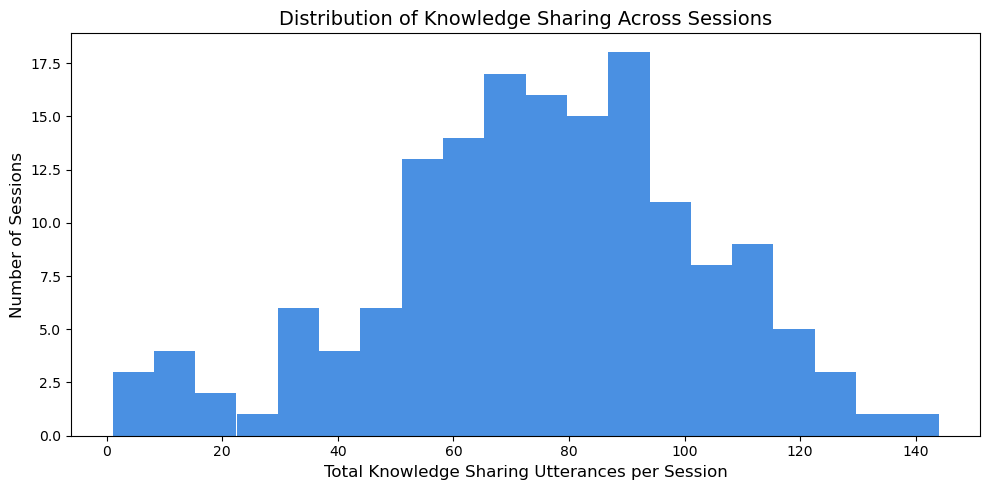

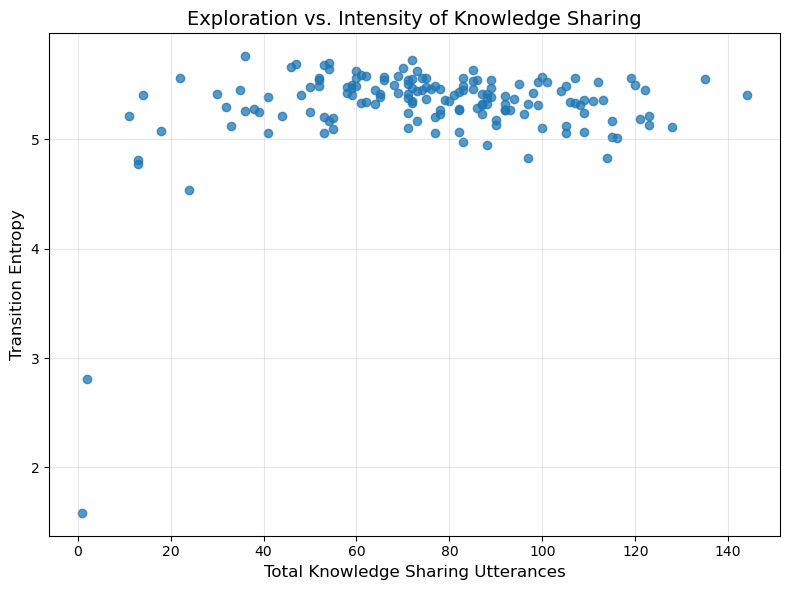

Mean KS_total_utterances by conference:
  conference  mean_KS_total
0    2020NES      35.562500
1    2021ABI      83.840000
2    2021CMC      71.285714
3    2021MND      73.625000
4    2021MZT      64.600000
5    2021NES      92.166667
6    2021SLU      80.000000
7    2022MND      89.722222


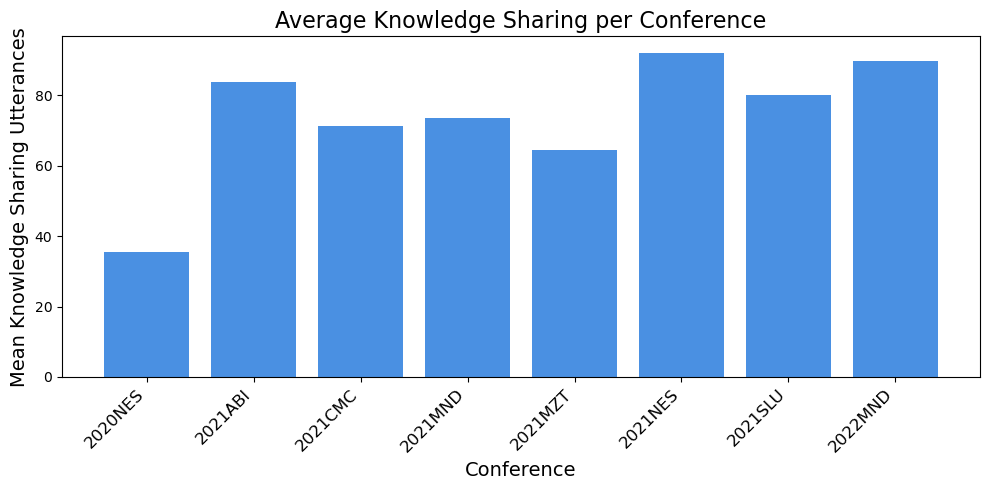

Saved modeling-ready features to:
  /Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. COMPACT SUMMARY TABLE FOR SLIDES
# ---------------------------------------------
# Pick a subset of the 38 columns that tell the clearest story
cols_for_summary = [
    "conference", "session",
    "n_utterances", "n_speakers", "max_time",
    "Beginning", "Middle", "End",
    "Idea_Management", "Information_Seeking", "Knowledge_Sharing",
    "Evaluation_Practices", "Relational_Climate",
    "KS_total_utterances", "KS_streak_count",
    "KS_max_streak_len", "KS_mean_streak_len",
    "KS_first_minute", "KS_last_minute", "KS_mean_minute",
    "n_transitions", "n_unique_pairs", "transition_entropy",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]

# Keep only the columns that actually exist (safety check)
cols_for_summary = [c for c in cols_for_summary if c in df_session_linkography.columns]

df_summary = df_session_linkography[cols_for_summary].copy()

# Example: sort by total KS to see the most KS-heavy sessions
df_summary_sorted = df_summary.sort_values("KS_total_utterances", ascending=False)

print("df_summary_sorted (top 10 by total KS):")
print(df_summary_sorted.head(10))

# ---------------------------------------------
# 2. OVERVIEW PLOTS ACROSS ALL SESSIONS
# ---------------------------------------------
# (a) Distribution of KS across sessions
plt.figure(figsize=(10, 5))
plt.hist(df_session_linkography["KS_total_utterances"], bins=20, color="#4A90E2")
plt.xlabel("Total Knowledge Sharing Utterances per Session", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.title("Distribution of Knowledge Sharing Across Sessions", fontsize=14)
plt.tight_layout()
plt.show()

# (b) KS intensity vs transition entropy
plt.figure(figsize=(8, 6))
plt.scatter(
    df_session_linkography["KS_total_utterances"],
    df_session_linkography["transition_entropy"],
    alpha=0.75
)
plt.xlabel("Total Knowledge Sharing Utterances", fontsize=12)
plt.ylabel("Transition Entropy", fontsize=12)
plt.title("Exploration vs. Intensity of Knowledge Sharing", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (c) Mean KS_total by conference
if "conference" in df_session_linkography.columns:
    mean_ks_by_conf = (
        df_session_linkography
        .groupby("conference")["KS_total_utterances"]
        .mean()
        .reset_index(name="mean_KS_total")
    )
    print("Mean KS_total_utterances by conference:")
    print(mean_ks_by_conf)

    plt.figure(figsize=(10, 5))
    plt.bar(mean_ks_by_conf["conference"],
            mean_ks_by_conf["mean_KS_total"],
            color="#4A90E2")
    plt.title("Average Knowledge Sharing per Conference", fontsize=16)
    plt.xlabel("Conference", fontsize=14)
    plt.ylabel("Mean Knowledge Sharing Utterances", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# 3. EXPORT THE MODELING-READY TABLE
# ---------------------------------------------
out_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv"
df_session_linkography.to_csv(out_path, index=False)
print(f"Saved modeling-ready features to:\n  {out_path}")

# Identifying Team Success - for 2021ABI

Based on funding status, etc.

In [11]:
import json
import pandas as pd

# ---------------------------------------------------
# 1. LOAD THE 2021 ABI OUTCOME JSON
# ---------------------------------------------------
json_path = json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(json_path, "r") as f:
    abi_data = json.load(f)

# ---------------------------------------------------
# 2. PARSE EACH SESSION INTO A FLAT ROW
# ---------------------------------------------------
rows = []
for session_id, detail in abi_data.items():

    # skip metadata keys like "missing_names"
    if not session_id.startswith("2021"):
        continue

    teams = detail.get("teams", {})

    # number of total teams
    n_teams = len(teams)

    # number of funded teams
    n_funded = sum(team_info.get("funded_status", 0) for team_info in teams.values())

    # did the session produce *any* funded outcomes?
    funded_any = 1 if n_funded > 0 else 0

    # append row
    rows.append({
        "session": session_id,
        "conference": "2021ABI",
        "n_teams": n_teams,
        "n_funded": n_funded,
        "funded_any": funded_any
    })

# convert to DataFrame
df_success = pd.DataFrame(rows)

print("\nParsed Success Table (2021 ABI):")
print(df_success.head(), "\n")
print(df_success)

# ---------------------------------------------------
# 3. MERGE WITH YOUR LINKOGRAPHY FEATURES
# ---------------------------------------------------
df_merged = df_session_linkography.merge(
    df_success,
    on=["conference", "session"],
    how="left"
)

print("\nMerged Shape:", df_merged.shape)
print(df_merged[["conference","session","n_teams","n_funded","funded_any"]].head())


Parsed Success Table (2021 ABI):
              session conference  n_teams  n_funded  funded_any
0   2021_05_20_ABI_S5    2021ABI        1         0           0
1   2021_05_20_ABI_S4    2021ABI        2         2           1
2  2021_05_21_ABI_S16    2021ABI        0         0           0
3   2021_05_21_ABI_S1    2021ABI        0         0           0
4   2021_05_20_ABI_S8    2021ABI        1         0           0 

               session conference  n_teams  n_funded  funded_any
0    2021_05_20_ABI_S5    2021ABI        1         0           0
1    2021_05_20_ABI_S4    2021ABI        2         2           1
2   2021_05_21_ABI_S16    2021ABI        0         0           0
3    2021_05_21_ABI_S1    2021ABI        0         0           0
4    2021_05_20_ABI_S8    2021ABI        1         0           0
5   2021_05_21_ABI_S11    2021ABI        2         1           1
6    2021_05_20_ABI_S3    2021ABI        1         1           1
7    2021_05_21_ABI_S6    2021ABI        0         0        

In [12]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Clean ABI sessions (optional but nice)
# ---------------------------------------------------
abi_sessions = abi_sessions.copy()

# Drop that weird "output-..." row if you don’t want it
abi_sessions = abi_sessions[~abi_sessions["session"].str.startswith("output-")]

# Keep only rows with a valid funded_any label
abi_labeled = abi_sessions.dropna(subset=["funded_any"]).copy()
abi_labeled["funded_any"] = abi_labeled["funded_any"].astype(int)

# ---------------------------------------------------
# 2. Group summaries: funded vs not funded
# ---------------------------------------------------
group_summary = (
    abi_labeled
    .groupby("funded_any")
    .agg(
        KS_total_utterances_mean=("KS_total_utterances", "mean"),
        KS_max_streak_len_mean=("KS_max_streak_len", "mean"),
        KS_mean_streak_len_mean=("KS_mean_streak_len", "mean"),
        transition_entropy_mean=("transition_entropy", "mean"),
        n_teams_mean=("n_teams", "mean"),
        n_funded_mean=("n_funded", "mean"),
    )
    .reset_index()
)

group_summary["funded_any_label"] = group_summary["funded_any"].map(
    {0: "No funded team", 1: "≥1 funded team"}
)

print("\nGroup means (funded_any = 0 vs 1):")
print(group_summary)

# ---------------------------------------------------
# 3. Simple plots for slides (ABI only)
# ---------------------------------------------------

# A) KS_total_utterances by funded_any (scatter "strips")
plt.figure(figsize=(6, 4))
for label, grp in abi_labeled.groupby("funded_any"):
    xs = [label] * len(grp)
    plt.scatter(xs, grp["KS_total_utterances"], alpha=0.6)

plt.xticks([0, 1], ["No funded team", "≥1 funded team"])
plt.ylabel("Total Knowledge Sharing Utterances")
plt.title("Knowledge Sharing vs. Funding Outcome (2021 ABI)")
plt.tight_layout()
plt.show()

# B) Boxplots for a couple of key features
features_to_box = ["KS_total_utterances", "KS_max_streak_len", "transition_entropy"]

for feat in features_to_box:
    plt.figure(figsize=(6, 4))
    abi_labeled.boxplot(column=feat, by="funded_any")
    plt.xticks([1, 2], ["No funded team", "≥1 funded team"])
    plt.xlabel("")
    plt.title(f"{feat} by Funding Outcome (2021 ABI)")
    plt.suptitle("")  # remove pandas' default super-title
    plt.tight_layout()
    plt.show()

NameError: name 'abi_sessions' is not defined

In [ ]:
import json
import pandas as pd

# ---------------------------------------------------
# 1. LOAD + PARSE 2021 ABI SESSION OUTCOMES
# ---------------------------------------------------
abi_json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(abi_json_path, "r") as f:
    abi_raw = json.load(f)

print("Top-level type for ABI JSON:", type(abi_raw))

rows = []

# Expected structure (dict):
# {
#   "2021_05_20_ABI_S4": {
#       "teams": {
#           "ABI13": {
#               "members": [...],
#               "funded_status": 1
#           },
#           ...
#       },
#       ...
#   },
#   "2021_05_21_ABI_S11": { ... },
#   ...
# }
if isinstance(abi_raw, dict):
    for sess_id, sess_data in abi_raw.items():
        # Skip any non-dict top-level entries (e.g., metadata keys)
        if not isinstance(sess_data, dict):
            continue

        teams_dict = sess_data.get("teams", {})
        if not isinstance(teams_dict, dict):
            # No valid team info
            n_teams = 0
            n_funded = 0
        else:
            n_teams = 0
            n_funded = 0
            for team_id, team_info in teams_dict.items():
                if not isinstance(team_info, dict):
                    continue
                n_teams += 1
                status = team_info.get("funded_status", 0)
                try:
                    status_int = int(status)
                except Exception:
                    status_int = 0
                if status_int == 1:
                    n_funded += 1

        rows.append({
            "conference": "2021ABI",
            "session": sess_id,
            "n_teams": n_teams,
            "n_funded": n_funded,
        })

else:
    print("Unexpected ABI JSON structure; expected dict at top level.")
    rows = []

df_abi_success = pd.DataFrame(rows)

print("\n🔥 Parsed ABI success table (non-zero funded rows):")
print(
    df_abi_success[df_abi_success["n_funded"] > 0]
    .sort_values(["session"])
    .to_string(index=False)
)

print("\nAll ABI success rows (first 10):")
print(df_abi_success.head(10).to_string(index=False))


# ---------------------------------------------------
# 2. MERGE WITH LINKOGRAPHY TABLE (ABI ONLY)
# ---------------------------------------------------
# Assumes df_session_linkography already exists
df_abi_link = df_session_linkography[
    df_session_linkography["conference"] == "2021ABI"
].copy()

# Drop any stale success columns if they exist
df_abi_link = df_abi_link.drop(
    columns=["n_teams", "n_funded", "funded_any"],
    errors="ignore"
)

# Merge success labels onto ABI linkography rows
merged_abi = df_abi_link.merge(
    df_abi_success,
    on=["conference", "session"],
    how="left"
)

# Keep only "real" session ids (skip any weird "output-..." rows if they exist)
mask_real = merged_abi["session"].str.startswith("2021_")
merged_abi = merged_abi[mask_real].copy()

# Fill missing success labels (if any) with 0
for col in ["n_teams", "n_funded"]:
    merged_abi[col] = merged_abi[col].fillna(0).astype(int)

print("\n✅ ABI sessions after merge (session + success columns):")
print(
    merged_abi[["session", "n_teams", "n_funded"]]
    .sort_values("session")
    .to_string(index=False)
)


# ---------------------------------------------------
# 3. FUNDED VS NOT-FUNDED BEHAVIORAL SUMMARY
#    (using n_funded > 0 instead of funded_any)
# ---------------------------------------------------
# Create a binary grouping based on whether any teams were funded
merged_abi["funded_group"] = (merged_abi["n_funded"] > 0).astype(int)
merged_abi["funded_group_label"] = merged_abi["funded_group"].map({
    0: "No funded team",
    1: "≥1 funded team"
})

# Columns to compare between funded vs non-funded sessions
cols_to_compare = [
    "KS_total_utterances",
    "KS_streak_count",
    "KS_max_streak_len",
    "KS_mean_streak_len",
    "KS_beginning",
    "KS_middle",
    "KS_end",
    "transition_entropy",
]

group_table = (
    merged_abi
    .groupby("funded_group_label")[cols_to_compare]
    .mean()
    .reset_index()
)

# Optional: round for slide readability
group_table[cols_to_compare] = group_table[cols_to_compare].round(3)

# Make funded_group_label the index for a clean printout
group_table = group_table.set_index("funded_group_label")

print("\n===== ABI 2021 — Behavioral Differences (Funded vs Not) =====")
print(group_table.to_string())

Top-level type for ABI JSON: <class 'dict'>

🔥 Parsed ABI success table (non-zero funded rows):
conference            session  n_teams  n_funded
   2021ABI  2021_05_20_ABI_S3        1         1
   2021ABI  2021_05_20_ABI_S4        2         2
   2021ABI  2021_05_20_ABI_S6        2         1
   2021ABI  2021_05_20_ABI_S7        1         1
   2021ABI 2021_05_21_ABI_S11        2         1
   2021ABI 2021_05_21_ABI_S12        3         1
   2021ABI 2021_05_21_ABI_S13        2         1
   2021ABI 2021_05_21_ABI_S15        2         1
   2021ABI  2021_05_21_ABI_S2        3         1
   2021ABI  2021_05_21_ABI_S7        3         1

All ABI success rows (first 10):
conference            session  n_teams  n_funded
   2021ABI  2021_05_20_ABI_S5        1         0
   2021ABI  2021_05_20_ABI_S4        2         2
   2021ABI 2021_05_21_ABI_S16        0         0
   2021ABI  2021_05_21_ABI_S1        0         0
   2021ABI  2021_05_20_ABI_S8        1         0
   2021ABI 2021_05_21_ABI_S11        

# Directionality and Temporal Thirds

In [ ]:
import pandas as pd

# ---------------------------------------------------
# 1. Ensure we have a funded_any flag for ABI
# ---------------------------------------------------
# (Funded if at least one funded team in the session)
merged_abi["funded_any"] = (merged_abi["n_funded"] > 0).astype(int)

# ---------------------------------------------------
# 2. Build transition *directionality* features
#    (normalize each KS→X or X→KS by total transitions)
# ---------------------------------------------------
direction_cols = [
    "KS_to_KS",
    "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]

# avoid divide-by-zero
denom = merged_abi["n_transitions"].replace(0, pd.NA)

for col in direction_cols:
    merged_abi[f"{col}_prop"] = merged_abi[col] / denom

# Example: KS_to_Idea_prop = proportion of all transitions that are KS→Idea


# ---------------------------------------------------
# 3. Build *temporal thirds* features for KS
#    (how KS is distributed across beginning/middle/end)
# ---------------------------------------------------
ks_total = merged_abi["KS_total_utterances"].replace(0, pd.NA)

merged_abi["KS_beginning_prop"] = merged_abi["KS_beginning"] / ks_total
merged_abi["KS_middle_prop"]    = merged_abi["KS_middle"]    / ks_total
merged_abi["KS_end_prop"]       = merged_abi["KS_end"]       / ks_total

# Optional sanity check: these should be ~1.0 when there is KS
merged_abi["KS_prop_sum"] = (
    merged_abi["KS_beginning_prop"]
    + merged_abi["KS_middle_prop"]
    + merged_abi["KS_end_prop"]
)


# ---------------------------------------------------
# 4. Summarize: funded vs not-funded (ABI only)
# ---------------------------------------------------
cols_summary = [
    # overall KS
    "KS_total_utterances",
    # temporal distribution
    "KS_beginning_prop", "KS_middle_prop", "KS_end_prop",
    # directionality proportions
    "KS_to_Idea_prop", "Idea_to_KS_prop",
    "KS_to_Eval_prop", "Eval_to_KS_prop",
    "KS_to_Info_prop", "Info_to_KS_prop",
    "KS_to_Rel_prop", "Rel_to_KS_prop",
    # exploration baseline
    "transition_entropy",
]

group_temp_dir = (
    merged_abi
    .groupby("funded_any")[cols_summary]
    .mean()
    .reset_index()
)

group_temp_dir["funded_group_label"] = group_temp_dir["funded_any"].map({
    0: "No funded team",
    1: "≥1 funded team",
})

group_temp_dir = (
    group_temp_dir
    .set_index("funded_group_label")
    .drop(columns=["funded_any"])
    .sort_index()
)

print("\n===== ABI 2021 — Temporal & Directionality Features (Funded vs Not) =====")
print(group_temp_dir.to_string(float_format=lambda x: f"{x:0.3f}"))


===== ABI 2021 — Temporal & Directionality Features (Funded vs Not) =====
                    KS_total_utterances  KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  Idea_to_KS_prop  KS_to_Eval_prop  Eval_to_KS_prop  KS_to_Info_prop  Info_to_KS_prop  KS_to_Rel_prop  Rel_to_KS_prop  transition_entropy
funded_group_label                                                                                                                                                                                                                               
No funded team                   87.929              0.274           0.387        0.339            0.042            0.040            0.025            0.024            0.037            0.040           0.038           0.034               5.382
≥1 funded team                   85.100              0.348           0.359        0.292            0.046            0.044            0.029            0.025            0.037            0.042          

# STOP HERE.

# USE THESE FEATURES TO TRAIN A SIMPLE PREDICTIVE MODEL FOR TEAM SUCCESS
## Starting with ABI then will scale it

In [17]:
import json
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------------------------------------
# 1. REBUILD merged_abi  (ABI linkography + success labels)
# -------------------------------------------------------

abi_json_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json"

with open(abi_json_path, "r") as f:
    abi_raw = json.load(f)

rows = []
if isinstance(abi_raw, dict):
    for sess_id, sess_data in abi_raw.items():
        if not isinstance(sess_data, dict):
            continue

        teams = sess_data.get("teams", {})
        n_teams = 0
        n_funded = 0
        if isinstance(teams, dict):
            for team_id, info in teams.items():
                if not isinstance(info, dict):
                    continue
                n_teams += 1
                if int(info.get("funded_status", 0)) == 1:
                    n_funded += 1

        rows.append({
            "conference": "2021ABI",
            "session": sess_id,
            "n_teams": n_teams,
            "n_funded": n_funded,
        })
else:
    raise ValueError("Unexpected ABI JSON structure; expected dict at top level.")

df_abi_success = pd.DataFrame(rows)

# Filter ABI linkography rows
df_abi_link = df_session_linkography[
    df_session_linkography["conference"] == "2021ABI"
].copy()

# Drop any old success columns that might still be there
df_abi_link = df_abi_link.drop(
    columns=["n_teams", "n_funded", "funded_any"],
    errors="ignore"
)

# Merge success labels
merged_abi = df_abi_link.merge(
    df_abi_success,
    on=["conference", "session"],
    how="left"
)

# Keep only real ABI session IDs
merged_abi = merged_abi[merged_abi["session"].str.startswith("2021_")].copy()

# Fill missing success labels with 0
for col in ["n_teams", "n_funded"]:
    merged_abi[col] = merged_abi[col].fillna(0).astype(int)

# -------------------------------------------------------
# 2. CREATE TEMPORAL & DIRECTIONALITY PROPORTION FEATURES
# -------------------------------------------------------

df = merged_abi.copy()

# Avoid divide-by-zero
df["KS_total_utterances"] = df["KS_total_utterances"].replace(0, pd.NA)
df["n_transitions"] = df["n_transitions"].replace(0, pd.NA)

# Temporal thirds (KS counts already in df)
df["KS_beginning_prop"] = df["KS_beginning"] / df["KS_total_utterances"]
df["KS_middle_prop"]    = df["KS_middle"]    / df["KS_total_utterances"]
df["KS_end_prop"]       = df["KS_end"]       / df["KS_total_utterances"]

# Directionality counts → proportions out of all transitions
transition_pairs = [
    "KS_to_Idea",
    "Idea_to_KS",
    "KS_to_Eval",
    "Eval_to_KS",
    "KS_to_Info",
    "Info_to_KS",
    "KS_to_Rel",
    "Rel_to_KS",
]

for col in transition_pairs:
    if col in df.columns:
        df[col + "_prop"] = df[col] / df["n_transitions"]

# -------------------------------------------------------
# 3. MODEL SETUP: BINARY FUNDED LABEL
# -------------------------------------------------------

df["funded_binary"] = (df["n_funded"] > 0).astype(int)

# ---- choose a SMALL, safer subset of predictors ----
#   - drop KS_end_prop to avoid perfect sum-to-one collinearity
#   - keep just a couple of directionality features to start
candidate_features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "transition_entropy",
]

# Keep only those that actually exist in df
feature_cols = [c for c in candidate_features if c in df.columns]

print("Using these predictors:", feature_cols)
print("N sessions:", len(df))

# -------------------------------------------------------
# 4. LOGISTIC REGRESSION: funded vs not
# -------------------------------------------------------

if len(df["funded_binary"].unique()) == 1:
    print("⚠️ Only one class in funded_binary; logistic regression won’t run.")
else:
    formula_logit = "funded_binary ~ " + " + ".join(feature_cols)
    try:
        logit_model = smf.logit(formula_logit, data=df).fit()
        print("\n===== LOGISTIC REGRESSION: Funded vs Not (ABI 2021) =====")
        print(logit_model.summary())
    except np.linalg.LinAlgError:
        print("\n⚠️ Logistic regression failed due to singular matrix even after feature reduction.")
        print("   -> Try removing one more predictor or fit a univariate model (one feature at a time).")

# -------------------------------------------------------
# 5. NEGATIVE BINOMIAL: number of funded teams
# -------------------------------------------------------

if df["n_funded"].max() == 0:
    print("\n⚠️ All n_funded are 0; skipping negative binomial model.")
else:
    formula_nb = "n_funded ~ " + " + ".join(feature_cols)
    try:
        nb_model = smf.glm(
            formula_nb,
            data=df,
            family=sm.families.NegativeBinomial()
        ).fit()
        print("\n===== NEGATIVE BINOMIAL: Count of Funded Teams (ABI 2021) =====")
        print(nb_model.summary())
    except np.linalg.LinAlgError:
        print("\n⚠️ Negative binomial regression failed due to singular matrix.")
        print("   -> Again, reduce predictors or try one-feature-at-a-time models.")

Using these predictors: ['KS_beginning_prop', 'KS_middle_prop', 'KS_to_Idea_prop', 'Idea_to_KS_prop', 'transition_entropy']
N sessions: 24
Optimization terminated successfully.
         Current function value: 0.539100
         Iterations 6

===== LOGISTIC REGRESSION: Funded vs Not (ABI 2021) =====
                           Logit Regression Results                           
Dep. Variable:          funded_binary   No. Observations:                   24
Model:                          Logit   Df Residuals:                       18
Method:                           MLE   Df Model:                            5
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2063
Time:                        09:16:19   Log-Likelihood:                -12.938
converged:                       True   LL-Null:                       -16.301
Covariance Type:            nonrobust   LLR p-value:                    0.2420
                         coef    std err          z      P>|z|      

/opt/miniconda3/envs/gem_samp/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


# Yes, this is ready to scale to the other sessions

# SCALING FEATURE EXTRACTION + MODELING TO OTHER CONFERENCES

In [18]:
import json
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ============================================================
# 1. Function to load + merge team outcomes for ANY conference
# ============================================================

def load_conference_success(json_path, conference_name):
    """
    Reads a session_outcomes.json file and returns a DataFrame with:
    - session
    - n_teams
    - n_funded
    - conference
    """
    with open(json_path, "r") as f:
        raw = json.load(f)

    rows = []
    if isinstance(raw, dict):
        for sess_id, sess_data in raw.items():
            if not isinstance(sess_data, dict):
                continue

            teams = sess_data.get("teams", {})
            n_teams = 0
            n_funded = 0
            if isinstance(teams, dict):
                for _, info in teams.items():
                    if not isinstance(info, dict):
                        continue
                    n_teams += 1
                    if int(info.get("funded_status", 0)) == 1:
                        n_funded += 1

            rows.append({
                "conference": conference_name,
                "session": sess_id,
                "n_teams": n_teams,
                "n_funded": n_funded,
            })

    return pd.DataFrame(rows)


# ============================================================
# 2. Function to merge linkography + success + engineer features
# ============================================================

def build_feature_dataset(df_session_linkography, df_success):
    """
    Takes linkography and success tables for ONE conference,
    merges them, and computes the KS-based features.
    """
    df_link = df_session_linkography[
        df_session_linkography["conference"] == df_success["conference"].iloc[0]
    ].copy()

    # Drop stale columns
    df_link = df_link.drop(columns=["n_teams", "n_funded", "funded_any"], errors="ignore")

    # Merge success
    df = df_link.merge(df_success, on=["conference", "session"], how="left")

    # Keep only real session IDs
    df = df[df["session"].str.contains("_")].copy()

    # Fill success labels
    df["n_teams"] = df["n_teams"].fillna(0).astype(int)
    df["n_funded"] = df["n_funded"].fillna(0).astype(int)

    # ======= Feature Engineering =======
    df["KS_total_utterances"] = df["KS_total_utterances"].replace(0, pd.NA)
    df["n_transitions"] = df["n_transitions"].replace(0, pd.NA)

    # Temporal proportions
    df["KS_beginning_prop"] = df["KS_beginning"] / df["KS_total_utterances"]
    df["KS_middle_prop"] = df["KS_middle"] / df["KS_total_utterances"]
    df["KS_end_prop"] = df["KS_end"] / df["KS_total_utterances"]

    # Directionality proportions
    transition_pairs = [
        "KS_to_Idea", "Idea_to_KS",
        "KS_to_Eval", "Eval_to_KS",
        "KS_to_Info", "Info_to_KS",
        "KS_to_Rel",  "Rel_to_KS",
    ]
    for col in transition_pairs:
        if col in df.columns:
            df[col + "_prop"] = df[col] / df["n_transitions"]

    # Binary funded label
    df["funded_binary"] = (df["n_funded"] > 0).astype(int)

    return df


# ============================================================
# 3. LOAD ALL CONFERENCES
# ============================================================

# ---- Already done for ABI ----
df_abi_success = load_conference_success(
    "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/2021ABI_session_outcomes.json",
    "2021ABI"
)

# ---- TODO: Add other conferences here ----
# Example placeholders — fill in real paths when ready
# df_mzt_success = load_conference_success("path/to/MZT_session_outcomes.json", "MZT")
# df_2022ABI_success = load_conference_success("path/to/2022ABI_session_outcomes.json", "2022ABI")

# ============================================================
# 4. BUILD FEATURE DATASETS FOR EACH CONFERENCE
# ============================================================

df_abi = build_feature_dataset(df_session_linkography, df_abi_success)

# When ready:
# df_mzt = build_feature_dataset(df_session_linkography, df_mzt_success)
# df_2022ABI = build_feature_dataset(df_session_linkography, df_2022ABI_success)

# ============================================================
# 5. CONCAT ALL CONFERENCE DATASETS (THIS IS THE BIG STEP)
# ============================================================

df_list = [df_abi]  # add others when ready

df_all = pd.concat(df_list, ignore_index=True)

print("Total sessions in df_all:", len(df_all))


# ============================================================
# 6. RUN LOGISTIC + NEGATIVE BINOMIAL MODELS ON df_all
# ============================================================

candidate_features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

feature_cols = [c for c in candidate_features if c in df_all.columns]

# Logistic
if df_all["funded_binary"].nunique() > 1:
    formula_logit = "funded_binary ~ " + " + ".join(feature_cols)
    logit_model = smf.logit(formula_logit, data=df_all).fit()
    print("\n===== LOGIT MODEL: ALL CONFERENCES =====")
    print(logit_model.summary())

# Negative binomial
if df_all["n_funded"].max() > 0:
    formula_nb = "n_funded ~ " + " + ".join(feature_cols)
    nb_model = smf.glm(
        formula_nb,
        data=df_all,
        family=sm.families.NegativeBinomial()
    ).fit()
    print("\n===== NEGATIVE BINOMIAL: ALL CONFERENCES =====")
    print(nb_model.summary())

Total sessions in df_all: 24
Optimization terminated successfully.
         Current function value: 0.489469
         Iterations 9

===== LOGIT MODEL: ALL CONFERENCES =====
                           Logit Regression Results                           
Dep. Variable:          funded_binary   No. Observations:                   24
Model:                          Logit   Df Residuals:                       15
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2793
Time:                        09:36:15   Log-Likelihood:                -11.747
converged:                       True   LL-Null:                       -16.301
Covariance Type:            nonrobust   LLR p-value:                    0.3334
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            

/opt/miniconda3/envs/gem_samp/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## sanity checking the 2021ABI

At some point I thought it was one sesh per json file... not the case. 

In [19]:
import os
import pandas as pd

# --------------------------------------------
# 1. Sessions from linkography dataframe
# --------------------------------------------
abi_link_sessions = sorted(
    df_session_linkography[df_session_linkography["conference"]=="2021ABI"]["session"].unique()
)

print("ABI sessions in LINKOGRAPHY (Gemini annotations):")
print(len(abi_link_sessions), abi_link_sessions)


# --------------------------------------------
# 2. Sessions from the outcomes JSON folder
# --------------------------------------------
json_folder = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data"

json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

abi_json_sessions = sorted([
    f.replace(".json","")   # e.g., "2021_05_20_ABI_S8"
    for f in json_files
    if f.startswith("2021")
])

print("\nABI sessions with OUTCOME JSON:")
print(len(abi_json_sessions), abi_json_sessions)


# --------------------------------------------
# 3. Missing JSON (these get n_funded=0, n_teams=0)
# --------------------------------------------
missing = sorted(list(set(abi_link_sessions) - set(abi_json_sessions)))
print("\nABI sessions MISSING JSON (treated as 0 funded):")
print(len(missing), missing)

# --------------------------------------------
# 4. Sessions with JSON (normal funded/non-funded)
# --------------------------------------------
present = sorted(list(set(abi_link_sessions) & set(abi_json_sessions)))
print("\nABI sessions WITH JSON (normal metadata):")
print(len(present), present)

ABI sessions in LINKOGRAPHY (Gemini annotations):
25 ['2021_05_20_ABI_S1', '2021_05_20_ABI_S2', '2021_05_20_ABI_S3', '2021_05_20_ABI_S4', '2021_05_20_ABI_S5', '2021_05_20_ABI_S6', '2021_05_20_ABI_S7', '2021_05_20_ABI_S8', '2021_05_21_ABI_S1', '2021_05_21_ABI_S10', '2021_05_21_ABI_S11', '2021_05_21_ABI_S12', '2021_05_21_ABI_S13', '2021_05_21_ABI_S14', '2021_05_21_ABI_S15', '2021_05_21_ABI_S16', '2021_05_21_ABI_S2', '2021_05_21_ABI_S3', '2021_05_21_ABI_S4', '2021_05_21_ABI_S5', '2021_05_21_ABI_S6', '2021_05_21_ABI_S7', '2021_05_21_ABI_S8', '2021_05_21_ABI_S9', 'output-2021-05-20-ABI-S1']

ABI sessions with OUTCOME JSON:
24 ['2021_05_20_ABI_S1', '2021_05_20_ABI_S2', '2021_05_20_ABI_S3', '2021_05_20_ABI_S4', '2021_05_20_ABI_S5', '2021_05_20_ABI_S6', '2021_05_20_ABI_S7', '2021_05_20_ABI_S8', '2021_05_21_ABI_S1', '2021_05_21_ABI_S10', '2021_05_21_ABI_S11', '2021_05_21_ABI_S12', '2021_05_21_ABI_S13', '2021_05_21_ABI_S14', '2021_05_21_ABI_S15', '2021_05_21_ABI_S16', '2021_05_21_ABI_S2', '2021_

In [20]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# 1. START FROM CLEANED df_all (after filtering)
# -------------------------------------------------------

df_all = df_all.copy()

# Make sure we exclude any artifact sessions like "output-2021..."
df_all = df_all[~df_all["session"].str.contains("output-")].copy()

# Safety: replace zeros for proportions with NA for averaging
prop_cols = [
    "KS_beginning_prop", "KS_middle_prop", "KS_end_prop",
    "KS_to_Idea_prop", "Idea_to_KS_prop",
    "KS_to_Eval_prop", "KS_to_Info_prop", "KS_to_Rel_prop",
    "transition_entropy"
]

# -------------------------------------------------------
# 2. GROUP BY CONFERENCE → COMPUTE MEAN VALUES
# -------------------------------------------------------

summary_table = df_all.groupby("conference")[prop_cols].mean()

# -------------------------------------------------------
# 3. ADD PERCENT-FUNDED COLUMN
# -------------------------------------------------------

summary_table["pct_sessions_funded"] = (
    df_all.groupby("conference")["funded_binary"].mean() * 100
)

# -------------------------------------------------------
# 4. ROUND FOR PRETTY OUTPUT
# -------------------------------------------------------

summary_table = summary_table.round(3)

print("\n===== CROSS-CONFERENCE SUMMARY TABLE =====")
print(summary_table)

# Save for slide deck if needed
summary_table.to_csv("cross_conference_summary.csv")


===== CROSS-CONFERENCE SUMMARY TABLE =====
            KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  \
conference                                                                    
2021ABI                 0.305           0.376        0.319            0.043   

            Idea_to_KS_prop  KS_to_Eval_prop  KS_to_Info_prop  KS_to_Rel_prop  \
conference                                                                      
2021ABI               0.042            0.027            0.037           0.038   

            transition_entropy  pct_sessions_funded  
conference                                           
2021ABI                  5.378               41.667  


In [28]:
import os
import json
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 0. Start from your existing linkography table
#    (one row per conference x session)
# ----------------------------------------------------
df_all = df_session_linkography.copy()

# ----------------------------------------------------
# 1. Temporal proportions (per session)
# ----------------------------------------------------
df_all["KS_total_utterances"] = df_all["KS_total_utterances"].replace(0, np.nan)

df_all["KS_beginning_prop"] = df_all["KS_beginning"] / df_all["KS_total_utterances"]
df_all["KS_middle_prop"]    = df_all["KS_middle"]    / df_all["KS_total_utterances"]
df_all["KS_end_prop"]       = df_all["KS_end"]       / df_all["KS_total_utterances"]

# ----------------------------------------------------
# 2. Directionality proportions (per session)
# ----------------------------------------------------
df_all["n_transitions"] = df_all["n_transitions"].replace(0, np.nan)

transition_pairs = [
    "KS_to_Idea",
    "Idea_to_KS",
    "KS_to_Eval",
    "Eval_to_KS",
    "KS_to_Info",
    "Info_to_KS",
    "KS_to_Rel",
    "Rel_to_KS",
]

for col in transition_pairs:
    if col in df_all.columns:
        df_all[col + "_prop"] = df_all[col] / df_all["n_transitions"]

# ----------------------------------------------------
# 3. Build funding labels ACROSS ALL CONFERENCES
#    (ABI, SLU, NES, CMC, MND, MZT, etc.)
# ----------------------------------------------------
BASE_PATH = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/"

fund_rows = []

for conf in os.listdir(BASE_PATH):
    conf_path = os.path.join(BASE_PATH, conf)
    if not os.path.isdir(conf_path):
        continue

    # We expect files like: 2021ABI_session_outcomes.json, 2021SLU_session_outcomes.json, ...
    outcomes_path = os.path.join(conf_path, f"{conf}_session_outcomes.json")
    if not os.path.exists(outcomes_path):
        continue

    with open(outcomes_path, "r") as f:
        raw = json.load(f)

    # ABI / SLU style: dict keyed by session_id, plus extras like "missing_names"
    if isinstance(raw, dict):
        for sess_id, sess_data in raw.items():
            if not isinstance(sess_data, dict):
                continue
            teams = sess_data.get("teams", {})
            if not isinstance(teams, dict):
                continue

            n_teams = 0
            n_funded = 0
            for _, tinfo in teams.items():
                if not isinstance(tinfo, dict):
                    continue
                n_teams += 1
                if int(tinfo.get("funded_status", 0)) == 1:
                    n_funded += 1

            fund_rows.append({
                "conference": conf,
                "session": sess_id,
                "n_teams": n_teams,
                "n_funded": n_funded,
            })

df_funding_all = pd.DataFrame(fund_rows)

# ----------------------------------------------------
# 4. Merge funding into linkography table
# ----------------------------------------------------
df_all = df_all.merge(
    df_funding_all[["conference", "session", "n_funded"]],
    on=["conference", "session"],
    how="left"
)

df_all["n_funded"] = df_all["n_funded"].fillna(0).astype(int)
df_all["funded_binary"] = (df_all["n_funded"] > 0).astype(int)

# ----------------------------------------------------
# 5. Cross-conference summary
# ----------------------------------------------------
summary_cols = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

summary_table = (
    df_all
    .groupby("conference")[summary_cols]
    .mean()
)

# percentage of funded sessions per conference
funded_summary = (
    df_all
    .groupby("conference")["funded_binary"]
    .mean()
    .mul(100)
    .rename("pct_sessions_funded")
)

summary_table = summary_table.join(funded_summary)

print("===== CROSS-CONFERENCE SUMMARY TABLE =====")
print(summary_table.round(3).to_string())

===== CROSS-CONFERENCE SUMMARY TABLE =====
            KS_beginning_prop  KS_middle_prop  KS_end_prop  KS_to_Idea_prop  Idea_to_KS_prop  KS_to_Eval_prop  KS_to_Info_prop  KS_to_Rel_prop  transition_entropy  pct_sessions_funded
conference                                                                                                                                                                             
2020NES                 0.336           0.337        0.327            0.051            0.046            0.032            0.047           0.031               5.177               50.000
2021ABI                 0.304           0.375        0.321            0.043            0.041            0.026            0.037           0.037               5.380               40.000
2021CMC                 0.319           0.326        0.354            0.039            0.037            0.019            0.037           0.042               5.431               52.381
2021MND                 0.330        

In [29]:
# Basic sanity check: sessions + funded sessions per conference
conf_check = (
    df_all
    .groupby("conference")
    .agg(
        n_sessions=("session", "nunique"),
        n_sessions_funded=("funded_binary", lambda x: int((x > 0).sum())),
        pct_sessions_funded=("funded_binary", lambda x: float((x > 0).mean() * 100)),
        total_teams=("n_funded", lambda x: int((x > 0).sum() + (x == 0).sum())),  # teams proxy
        total_funded_teams=("n_funded", "sum")
    )
)

print("=== CONFERENCE FUNDING CHECK ===")
print(conf_check.round(3).to_string())

=== CONFERENCE FUNDING CHECK ===
            n_sessions  n_sessions_funded  pct_sessions_funded  total_teams  total_funded_teams
conference                                                                                     
2020NES             16                  8               50.000           16                  10
2021ABI             25                 10               40.000           25                  11
2021CMC             21                 11               52.381           21                  14
2021MND             24                  5               20.833           24                   5
2021MZT             15                  8               53.333           15                  14
2021NES             18                 10               55.556           18                  11
2021SLU             20                 10               50.000           20                  12
2022MND             18                  6               33.333           18                   6


In [30]:
conf = "2021SLU"

print(f"\n=== {conf}: session-level funding ===")
slu_sessions = (
    df_all[df_all["conference"] == conf]
    .loc[:, ["session", "n_funded", "funded_binary"]]
    .sort_values("session")
)

print(slu_sessions.to_string(index=False))

print("\nCounts for 2021SLU:")
print("Total sessions:", slu_sessions["session"].nunique())
print("Sessions with ≥1 funded team:",
      int((slu_sessions["n_funded"] > 0).sum()))
print("Pct funded sessions:",
      (slu_sessions["n_funded"] > 0).mean() * 100)


=== 2021SLU: session-level funding ===
           session  n_funded  funded_binary
 2021_06_10_SLU_S1         1              1
 2021_06_10_SLU_S2         1              1
 2021_06_10_SLU_S3         0              0
 2021_06_10_SLU_S4         2              1
 2021_06_10_SLU_S5         1              1
 2021_06_10_SLU_S6         0              0
 2021_06_10_SLU_S7         0              0
 2021_06_11_SLU_S1         1              1
2021_06_11_SLU_S10         0              0
2021_06_11_SLU_S11         1              1
2021_06_11_SLU_S12         0              0
2021_06_11_SLU_S13         0              0
 2021_06_11_SLU_S2         0              0
 2021_06_11_SLU_S3         1              1
 2021_06_11_SLU_S4         1              1
 2021_06_11_SLU_S5         0              0
 2021_06_11_SLU_S6         0              0
 2021_06_11_SLU_S7         1              1
 2021_06_11_SLU_S8         2              1
 2021_06_11_SLU_S9         0              0

Counts for 2021SLU:
Total sessions:

# EXTRACTING KS SEQUENCES

afterwards do the following:

compute per-session sequence features

visualize sequences

add features to success models

(then update slide deck)

In [32]:
import pandas as pd
import numpy as np

# df_all should already exist and contain:
# - conference, session
# - funded_binary (0/1)
# - KS_beginning_prop, KS_middle_prop, KS_end_prop
# - KS_to_Idea_prop, Idea_to_KS_prop, KS_to_Eval_prop, KS_to_Info_prop, KS_to_Rel_prop
# - transition_entropy

features = [
    "KS_beginning_prop",
    "KS_middle_prop",
    "KS_end_prop",
    "KS_to_Idea_prop",
    "Idea_to_KS_prop",
    "KS_to_Eval_prop",
    "KS_to_Info_prop",
    "KS_to_Rel_prop",
    "transition_entropy",
]

rows = []

for feat in features:
    if feat not in df_all.columns:
        continue

    median_val = df_all[feat].median()

    tmp = df_all.copy()
    tmp["high"] = (tmp[feat] >= median_val).astype(int)

    # Funding rate (% of sessions with >=1 funded team)
    fund_rates = tmp.groupby("high")["funded_binary"].mean().mul(100)

    rows.append({
        "feature": feat,
        "median_value": median_val,
        "fund_rate_high_pct": fund_rates.get(1, np.nan),
        "fund_rate_low_pct":  fund_rates.get(0, np.nan),
        "n_high_sessions": int(tmp["high"].sum()),
        "n_low_sessions":  int((1 - tmp["high"]).sum())
    })

df_feature_effects = (
    pd.DataFrame(rows)
    .sort_values("fund_rate_high_pct", ascending=False)
)

print("===== KS FEATURES vs FUNDING (ALL CONFERENCES) =====")
print(df_feature_effects.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

===== KS FEATURES vs FUNDING (ALL CONFERENCES) =====
           feature  median_value  fund_rate_high_pct  fund_rate_low_pct  n_high_sessions  n_low_sessions
    KS_to_Rel_prop          0.04               48.72              37.97               78              79
transition_entropy          5.38               48.72              37.97               78              79
 KS_beginning_prop          0.33               46.84              39.74               79              78
    KS_middle_prop          0.32               45.57              41.03               79              78
   KS_to_Info_prop          0.04               43.59              43.04               78              79
   KS_to_Idea_prop          0.04               42.31              44.30               78              79
   Idea_to_KS_prop          0.04               41.03              45.57               78              79
   KS_to_Eval_prop          0.02               37.18              49.37               78              79
  

# EXTRACTING THE SEQUENCES

In [43]:
# ============================================================
# RUN KS SEQUENCE PIPELINE ON REAL UTTERANCE DATA
# (auto-detect likely utterance CSV, then compute features)
# ============================================================

import os
import json
import pandas as pd

# ---------- 0) FIND CANDIDATE UTTERANCE CSV FILES ----------
CANDIDATE_UTT = []

for root, dirs, files in os.walk(".", topdown=True):
    for f in files:
        name = f.lower()
        if (
            name.endswith(".csv")
            and ("utt" in name or "utterance" in name or "scialog" in name)
        ):
            CANDIDATE_UTT.append(os.path.join(root, f))

print("🔎 Candidate utterance-level CSV files I found:")
if not CANDIDATE_UTT:
    raise FileNotFoundError(
        "❌ No CSV files with 'utt', 'utterance', or 'scialog' in the name were found.\n"
        "👉 Make sure your NEW utterance export (with all conferences) is in this repo/folder.\n"
        "   Once it is, re-run this cell."
    )

for i, path in enumerate(CANDIDATE_UTT):
    print(f"  [{i}] {path}")

# ---------- 1) CHOOSE WHICH FILE TO USE ----------
# 👉 EDIT THIS INDEX if the "right" file is not [0].
UTT_INDEX = 0   # e.g., change to 1 or 2 if needed based on the list above

UTT_PATH = CANDIDATE_UTT[UTT_INDEX]
print(f"\n📂 Using utterance data from: {UTT_PATH}")

# ---------- 2) LOAD UTTERANCE-LEVEL DATA ----------
df_utt_all = pd.read_csv(UTT_PATH)

print("✅ df_utt_all loaded.")
print("   shape:", df_utt_all.shape)
print("   columns:", df_utt_all.columns.tolist())
print()

# ---------- 3) ENSURE annotation_dict IS A DICT ----------
if "annotation_dict" not in df_utt_all.columns:
    raise ValueError(
        "❌ 'annotation_dict' column not found in df_utt_all.\n"
        f"   Columns are: {df_utt_all.columns.tolist()}\n"
        "👉 If your new export uses a different name (e.g., 'annotations'), "
        "you'll need to rename it before parsing, e.g.:\n"
        "   df_utt_all['annotation_dict'] = df_utt_all['annotations']"
    )

def parse_annotation(x):
    # already a dict
    if isinstance(x, dict):
        return x
    # missing / NaN
    if pd.isna(x):
        return {}
    # string → try JSON
    try:
        return json.loads(x)
    except Exception:
        # fallback: empty dict rather than crash
        return {}

df_utt_all["annotation_dict"] = df_utt_all["annotation_dict"].apply(parse_annotation)

print("✅ annotation_dict parsed to dicts.")
print("   Example annotation_dict:", df_utt_all['annotation_dict'].iloc[0])
print()

# ---------- 4) COMPUTE SEQUENCE FEATURES ----------
print("⚙️  Computing KS sequence features...")
seq_features = compute_sequence_features(df_utt_all)

print("✅ seq_features created.")
print("   shape:", seq_features.shape)
print(seq_features.head())
print()

# ---------- 5) VISUALIZE SEQUENCES (OPTIONAL) ----------
try:
    print("📊 Making quick KS visualizations...")
    visualize_ks_sequences(seq_features, conference_filter=None)
    print("✅ Visualizations done.\n")
except Exception as e:
    print("⚠️  Skipping visualizations due to error:", e, "\n")

# ---------- 6) MERGE INTO SESSION-LEVEL TABLE (IF EXISTS) ----------
if "df_sessions" in globals():
    print("🔗 Merging seq_features into df_sessions...")
    df_with_seq = df_sessions.merge(
        seq_features,
        on=["conference", "session"],
        how="left"
    )
    print("✅ df_with_seq created with KS sequence features.")
    print("   shape:", df_with_seq.shape)
else:
    print("ℹ️  df_sessions not found in globals(); skipping merge step.")

🔎 Candidate utterance-level CSV files I found:


FileNotFoundError: ❌ No CSV files with 'utt', 'utterance', or 'scialog' in the name were found.
👉 Make sure your NEW utterance export (with all conferences) is in this repo/folder.
   Once it is, re-run this cell.